### Plantix - Prediction on Test Images

In [75]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2

##### Loading Model

In [76]:
model = tf.keras.models.load_model("C:/Users/Aadarsh/Desktop/Plantix/models/trained_model.keras")

In [77]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_11 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_12 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_13 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                  

##### Visualizing Single Image of Test set

In [78]:
image_path = "C:/Users/Aadarsh/Desktop/Plantix/data/test/PotatoHealthy2.JPG"

In [79]:
# Read Image
img = cv2.imread(image_path) #type: ignore
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR image to RGB #type: ignore

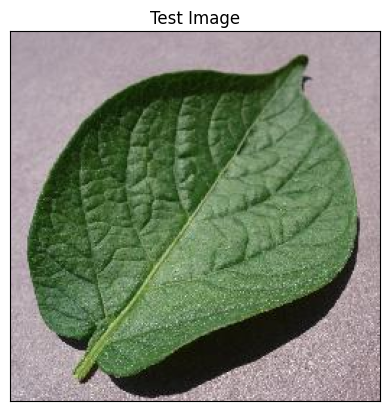

In [80]:
# Displaying image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

##### Testing Model

In [81]:
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
input_array = tf.keras.preprocessing.image.img_to_array(image)
input_array = np.array([input_array]) # Convert single image to batch

In [82]:
print(input_array.shape)

(1, 128, 128, 3)


In [83]:
prediction = model.predict(input_array)

1/1 [==============================] - 0s 300ms/step


In [84]:
prediction

array([[3.5353376e-05, 2.0484677e-08, 1.9579968e-01, 7.0402489e-06,
        1.2311806e-07, 3.5588514e-02, 5.5653666e-04, 3.2823639e-08,
        4.6595325e-08, 1.0220106e-08, 1.8238633e-09, 2.0665194e-08,
        2.8815714e-08, 4.0806283e-09, 4.6767767e-09, 5.0988984e-07,
        6.5860513e-06, 9.6476069e-06, 9.6727068e-05, 1.3753892e-03,
        3.6973831e-06, 7.6445866e-01, 1.9220127e-03, 1.7071142e-07,
        1.1297899e-04, 8.1522833e-09, 2.8572785e-07, 2.3447382e-09,
        8.8544372e-09, 1.8617524e-05, 2.1721391e-08, 4.2231727e-06,
        2.1803235e-07, 1.3612974e-09, 3.6666950e-07, 7.9431235e-09,
        2.4111680e-06, 2.5790434e-10]], dtype=float32)

In [85]:
prediction.shape

(1, 38)

In [86]:
result_index = np.argmax(prediction)

In [87]:
result_index

21

In [88]:
class_name = [
    'Apple Black Rot',
    'Apple Cedar Apple Rust',
    'Apple Healthy',
    'Apple Scab',
    'Blueberry Healthy',
    'Cherry(including sour) Healthy',
    'Cherry(including sour) Powdery Mildew',
    'Corn(maize) Cercospora Leaf Spot Gray Leaf Spot',
    'Corn(maize) Common Rust',
    'Corn(maize) Healthy',
    'Corn(maize) Northern Leaf Blight',
    'Grape Black Rot',
    'Grape Esca (Black Measles)',
    'Grape Healthy',
    'Grape Leaf Blight (Isariopsis Leaf Spot)',
    'Orange Haunglongbing (Citrus greening)',
    'Peach Bacterial Spot',
    'Peach Healthy',
    'Pepper Bell Bacterial Spot',
    'Pepper Bell Healthy',
    'Potato Early Blight',
    'Potato Healthy',
    'Potato Late Blight',
    'Raspberry Healthy',
    'Soybean Healthy',
    'Squash Powdery Mildew',
    'Strawberry Healthy',
    'Strawberry Leaf Scorch',
    'Tomato Bacterial Spot',
    'Tomato Early Blight',
    'Tomato Healthy',
    'Tomato Late Blight',
    'Tomato Leaf Mold',
    'Tomato Mosaic Virus',
    'Tomato Septoria Leaf Spot',
    'Tomato Spider Mites Two-spotted Spider Mite',
    'Tomato Target Spot',
    'Tomato Yellow Leaf Curl Virus'
]

In [89]:
# Displaying result of disease prediction
model_prediction = class_name[result_index]

In [90]:
model_prediction

'Potato Healthy'

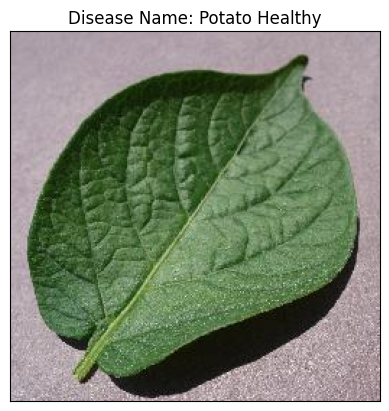

In [91]:
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()